Statement of use of AI

I used the OpenAI ChatGPT to check the code correctness. The suggested lines/methods of code, used in the assignment, are separately marked in each task. 

Task 0: Course project dataset exploration


Dataset name and link

I selected the dataset “Wearable Health Devices Performance Analysis”:

 - Source: Kaggle
 - Dataset link: https://www.kaggle.com/datasets/pratyushpuri/wearable-health-devices-performance-analysis




Dataset Description

The dataset contains performance evaluations of wearable health devices collected between June 1, 2025 and June 26, 2025. It includes a total of 2,375 observations (rows) and 17 variables (17 columns).

The dataset covers major wearable technology brands such as Apple, Samsung, Garmin, Fitbit, Huawei, Amazfit, WHOOP, Oura, Polar, and Withings. 

Devices are categorized into types such as smartwatches, fitness trackers, smart rings, fitness bands, and sports watches. The dataset covers the device technical specifications, performance metrics and user satisfaction ratings. 

The variables in the dataset include:

- Product information: 
    - test date, device name, brand, model, category.
- Market information: 
    - price in USD and app ecosystem support (iOS, Android, Cross-platform)
- Device specifications: 
    - battery life hours, number of sensors, connectivity features (Bluetooth, WiFi, NFC, LTE), and water resistance features (e.g., IP68, 5ATM).
- Performance metrics:
    - heart rate accuracy (%), step count accuracy (%), sleep tracking accuracy (%), GPS accuracy (meters)
- User perception: user satisfaction rating (1–10 scale)
- Overall evaluation: performance score (0–100), which represents a composite measure of device performance.

The aim of my project is to examine how device characteristics and price relate to both objective performance and subjective user satisfaction in wearable health devices. 

More specifically, I will address several research questions:
 - To what extent does device price predict overall performance score?
 - Which device features (e.g., battery life, accuracy metrics, number of sensors) influence user satisfaction ratings?

Although the dataset is synthetic, it provides a useful basis for practicing statistical analysis and exploring patterns relevant to digital health wearables. In particular, this project connects to my Master's thesis on digital health/wellness wearable technologies, where I examine user perceptions (perceived value) of wearable devices through a survey experiment. 

I will start with data cleaning and preprocessing (e.g., handling missing values, converting data types, etc.). Next, I will conduct exploratory data analysis (EDA) to understand the distribution of key variables (e.g., price, performance score, user satisfaction) and identify patterns across brands and device categories.

In [1]:
# connecting to the database file
import pandas as pd

df_wearables = pd.read_csv("wearable_health_devices_performance_upto_26june2025.csv")

# loading
df_wearables.head(10)

,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score
0,2025-06-01,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4
1,2025-06-01,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1
2,2025-06-01,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3
3,2025-06-01,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0
4,2025-06-01,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2
5,2025-06-01,Garmin Forerunner 965,Garmin,Forerunner 965,Smartwatch,402.32,287.4,92.85,99.34,77.58,5ATM,8.1,2.3,"WiFi, Bluetooth, NFC, LTE",11,Cross-platform,63.6
6,2025-06-01,Withings ScanWatch 2,Withings,ScanWatch 2,Sports Watch,235.64,219.2,96.41,94.22,79.07,5ATM,7.2,3.4,Bluetooth,9,Cross-platform,61.3
7,2025-06-01,Garmin Fenix 8,Garmin,Fenix 8,Smartwatch,897.85,589.9,93.65,99.27,75.23,5ATM,9.0,4.6,"WiFi, Bluetooth, NFC",14,Cross-platform,63.3
8,2025-06-01,Samsung Galaxy Watch Ultra,Samsung,Galaxy Watch Ultra,Smartwatch,318.18,36.4,92.33,96.83,82.94,5ATM,8.2,3.7,"WiFi, Bluetooth, NFC, LTE",15,Android/iOS,60.6
9,2025-06-01,WHOOP 4.0,WHOOP,4.0,Fitness Band,30.00,120.7,91.48,94.79,73.71,IPX4,6.1,NaN,Bluetooth,3,Android/iOS,67.1


In [2]:
# number of rows and columns
df_wearables.shape   

(2375, 17)

In [73]:
# dataset structure information
df_wearables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Test_Date                        2375 non-null   object 
 1   Device_Name                      2375 non-null   object 
 2   Brand                            2375 non-null   object 
 3   Model                            2375 non-null   object 
 4   Category                         2375 non-null   object 
 5   Price_USD                        2375 non-null   float64
 6   Battery_Life_Hours               2375 non-null   float64
 7   Heart_Rate_Accuracy_Percent      2375 non-null   float64
 8   Step_Count_Accuracy_Percent      2375 non-null   float64
 9   Sleep_Tracking_Accuracy_Percent  2375 non-null   float64
 10  Water_Resistance_Rating          2375 non-null   object 
 11  User_Satisfaction_Rating         2375 non-null   float64
 12  GPS_Accuracy_Meters 

In [3]:
#statistical summary

df_wearables.describe()

,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,User_Satisfaction_Rating,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
count,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,1743.000000,2375.000000,2375.000000
mean,359.444484,160.584463,93.483907,95.910198,78.837516,7.966484,3.247676,8.912842,64.047621
std,215.671035,234.815896,3.172078,1.665484,4.843714,0.831801,1.022825,3.559990,5.109075
min,30.000000,18.000000,85.010000,93.000000,70.000000,6.000000,1.500000,2.000000,55.100000
25%,211.875000,46.900000,92.140000,94.550000,75.610000,7.400000,2.400000,6.000000,60.400000
50%,334.370000,99.800000,94.070000,95.950000,78.300000,8.000000,3.200000,9.000000,62.200000
75%,487.930000,177.400000,95.925000,96.960000,81.930000,8.500000,4.100000,12.000000,67.700000
max,989.480000,2118.100000,98.000000,99.500000,91.970000,9.500000,5.000000,15.000000,78.300000


In [4]:
# checking missing data

df_wearables.isnull().sum() 

Test_Date                            0
Device_Name                          0
Brand                                0
Model                                0
Category                             0
Price_USD                            0
Battery_Life_Hours                   0
Heart_Rate_Accuracy_Percent          0
Step_Count_Accuracy_Percent          0
Sleep_Tracking_Accuracy_Percent      0
Water_Resistance_Rating              0
User_Satisfaction_Rating             0
GPS_Accuracy_Meters                632
Connectivity_Features                0
Health_Sensors_Count                 0
App_Ecosystem_Support                0
Performance_Score                    0
dtype: int64

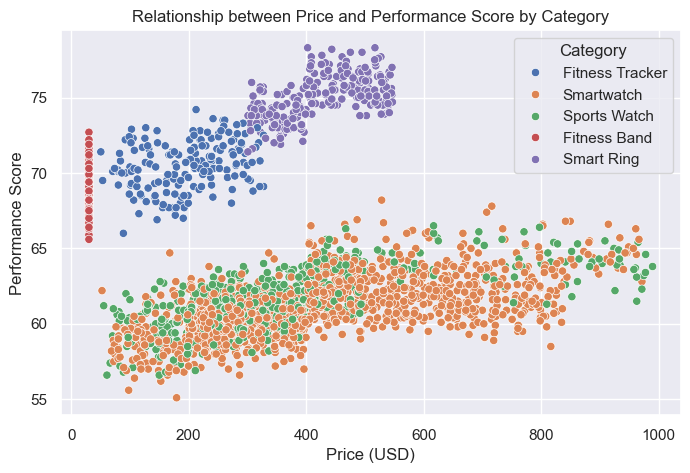

In [5]:
# scatterplot visualisation

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme() 

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_wearables, x="Price_USD", y="Performance_Score", hue="Category")

plt.title("Relationship between Price and Performance Score by Category")
plt.xlabel("Price (USD)")



plt.ylabel("Performance Score")
plt.show()

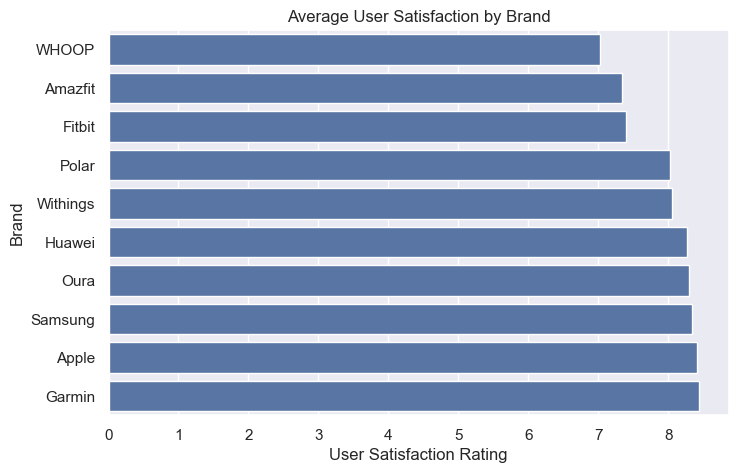

In [6]:
#correlation of satisfaction and the brand

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

brand_sat = df_wearables.groupby("Brand")["User_Satisfaction_Rating"].mean().sort_values()

sns.barplot(x=brand_sat.values, y=brand_sat.index)

plt.title("Average User Satisfaction by Brand")
plt.xlabel("User Satisfaction Rating")
plt.ylabel("Brand")
plt.show()

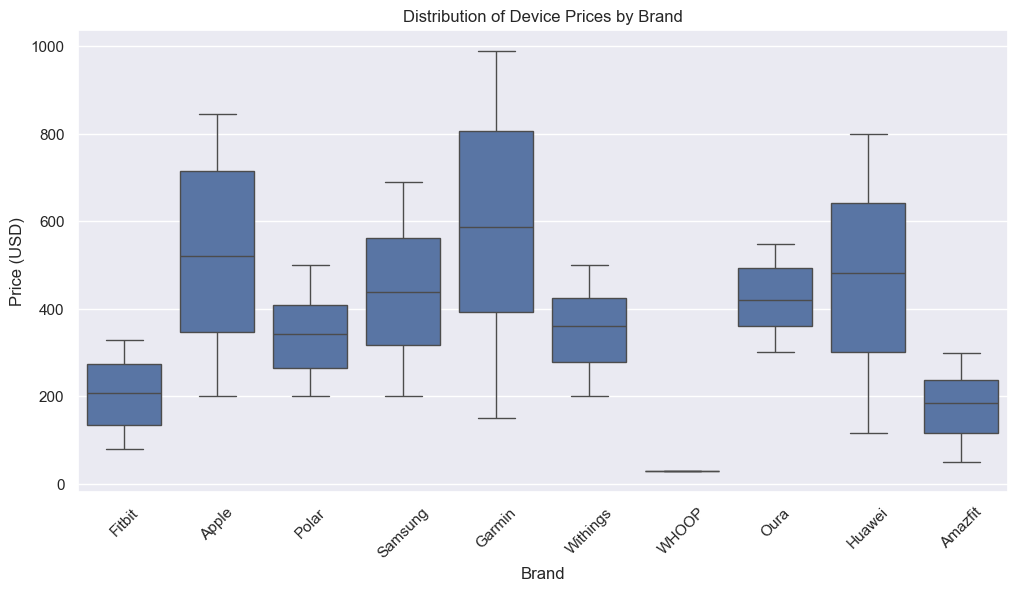

In [7]:
#boxplot comparing different brand  price distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_wearables,
    x="Brand",
    y="Price_USD"
)

plt.title("Distribution of Device Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

Task 1: Setting up an API key and .env file

In [8]:


# !pip install python-dotenv was done before, and python-dotenv is already installed

from dotenv import load_dotenv
import os

# Loading all variables from .env into the environment
load_dotenv()

api_key = os.environ.get("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")

e46ba...


Task 2: Retrieving data from MarketStack

In [9]:
#a) Retrieve End-of-Day (eod) data for five stocks for March 2026. 

import requests
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.environ.get("MARKETSTACK_API_KEY")

url = "https://api.marketstack.com/v2/eod"

params = {
    "access_key": api_key,
    "symbols": "AAPL,META,AMZN,NFLX,GOOG",
    "limit": 100,
    "date_from": "2026-03-01",
    "date_to": "2026-03-31"
}
    
response = requests.get(url, params=params)
stocks = response.json()

#checking for errors
print("Status code:", response.status_code)
if response.status_code == 200:
    print("Success")
else:
    print("Request failed")
print(stocks.keys())


Status code: 200
Success
dict_keys(['pagination', 'data'])


In [10]:
#b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

import pandas as pd

df = pd.DataFrame(stocks["data"])
df = df[["symbol", "date", "open", "close", "volume"]]
df["date"] = pd.to_datetime(df["date"]).dt.date #fixing date format  (*ChatGPT recommendation)

print(df.head())


  symbol        date     open   close      volume
0   AAPL  2026-03-31  247.890  253.79  48770963.0
1   AMZN  2026-03-31  204.875  208.27  57843337.0
2   GOOG  2026-03-31  277.840  286.86  30680107.0
3   META  2026-03-31  549.980  572.13  32809500.0
4   NFLX  2026-03-31   93.250   96.15  53674277.0


In [11]:
#c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

#summary statistics
summary = df.groupby("symbol")["close"].describe()
print(summary)

#return percentage
df = df.sort_values(["symbol", "date"]).reset_index(drop=True) #sorting data (*ChatGPT recommendation) keeping that from earliest to latest

returns = df.groupby("symbol")["close"].agg(["first", "last"]) #first and last are built-in aggregation functions, showing the beginning and end of month (first and last row in the order) (*ChatGPT recommendation)
returns["return_%"]= (returns["last"] - returns["first"])/returns["first"]*100
print(returns)

#best and worst performing stocks
print(f"Best performer: {returns['return_%'].idxmax()}")
print(f"Worst performer: {returns['return_%'].idxmin()}")
              

        count      mean        std     min       25%      50%       75%  \
symbol                                                                    
AAPL     20.0  253.9735   4.843451  246.63  250.0750  252.855  258.0650   
AMZN     20.0  210.1385   4.856686  199.34  207.6375  210.005  213.2800   
GOOG     20.0  297.2825  11.232111  273.14  289.4925  301.185  305.8000   
META     20.0  611.0580  41.315247  525.72  593.4750  614.695  645.4925   
NFLX     20.0   94.8445   2.518470   90.92   93.2325   94.530   96.3475   

           max  
symbol          
AAPL    262.52  
AMZN    218.94  
GOOG    309.41  
META    667.73  
NFLX     99.17  
         first    last   return_%
symbol                           
AAPL    262.52  253.79  -3.325461
AMZN    216.82  208.27  -3.943363
GOOG    303.45  286.86  -5.467128
META    667.73  572.13 -14.317164
NFLX     98.66   96.15  -2.544091
Best performer: NFLX
Worst performer: META


Task 3: Visualizing stock data

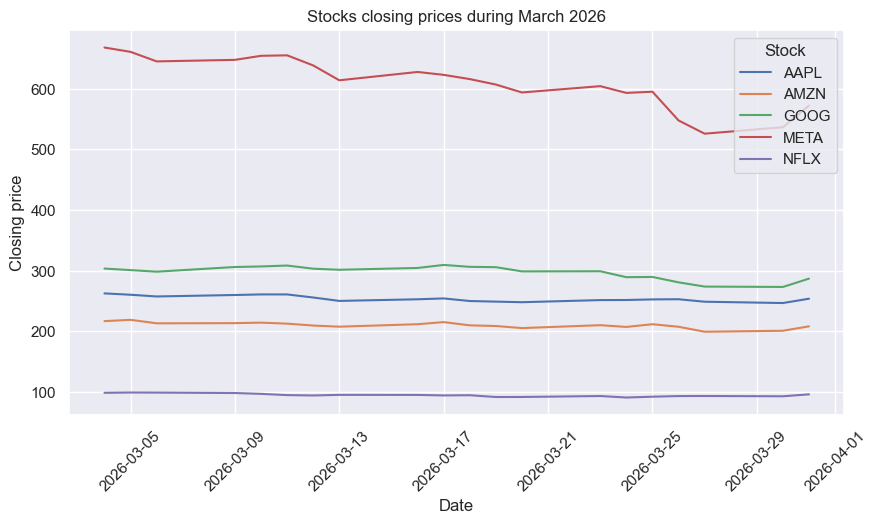

In [11]:
#a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='date', y='close', hue='symbol');

plt.title('Stocks closing prices during March 2026')
plt.xlabel('Date')
plt.ylabel('Closing price')
plt.xticks(rotation=45) #it helps to rotate the x-axis to avoid the overlapping of the same date (*ChatGPT suggestion)
plt.legend(title="Stock")

plt.show()


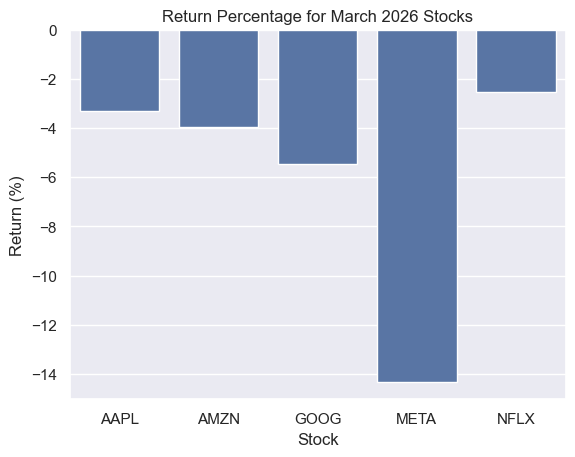

In [12]:
#b) A bar plot showing the overall return percentage for each stock in March 2026.


sns.barplot(data=returns, x='symbol', y='return_%'); #vertical bar

plt.title("Return Percentage for March 2026 Stocks")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.show()


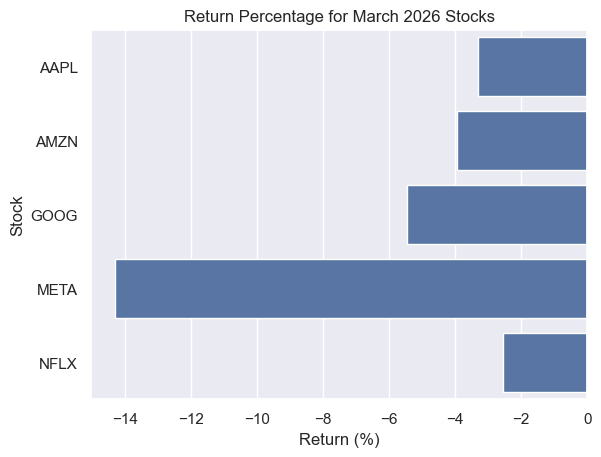

In [13]:
sns.barplot(data=returns.reset_index(), x="return_%", y="symbol"); #horisontal bar chat

plt.title("Return Percentage for March 2026 Stocks")
plt.xlabel("Return (%)")
plt.ylabel("Stock")
plt.show()

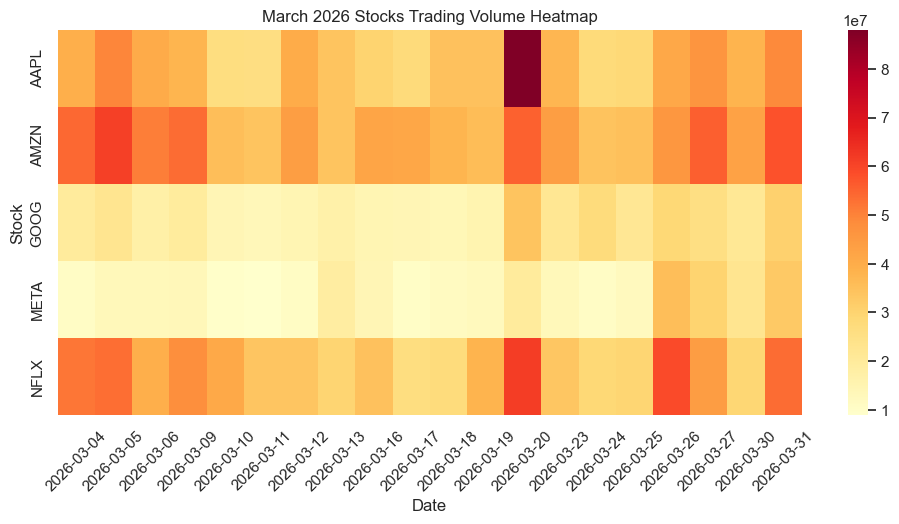

In [14]:
#c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

vol_df = df[["symbol", "date", "volume"]]

heatmap_data = vol_df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(12, 5))

sns.heatmap(heatmap_data, cmap="YlOrRd")

plt.title("March 2026 Stocks Trading Volume Heatmap")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.xticks(rotation=45) #(*ChatGPT suggestion)

plt.show()

Task 4: Exporting and importing data

In [15]:
#a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.


import os
import json

# Create the exports folder since it doesn't exist ((*ChatGPT suggestion))
os.makedirs("exports", exist_ok=True)


# Export using the json module
with open("exports/stockdata.json", "w") as f:
    json.dump(stocks, f, indent=2)

print("Exported via json module to exports/stockdata.json")



Exported via json module to exports/stockdata.json


In [16]:
#b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

import pandas as pd


# Export
df.to_csv("exports/stockdata.csv", index=False)

print("CSV exported to exports/stockdata.csv")


CSV exported to exports/stockdata.csv


In [17]:

import pandas as pd
import json

# Load JSON

with open("exports/stockdata.json", "r") as f:
    json_data = json.load(f)

df_json = pd.DataFrame(json_data["data"])
df_json = df_json[["symbol", "date", "open", "close", "volume"]]
df_json["date"] = pd.to_datetime(df_json["date"]).dt.date

print("JSON loaded:")
print(df_json.head())

# Load CSV
df_csv = pd.read_csv("exports/stockdata.csv")
df_csv["date"] = pd.to_datetime(df_csv["date"]).dt.date

print("\nCSV loaded:")
print(df_csv.head())


JSON loaded:
  symbol        date     open   close      volume
0   AAPL  2026-03-31  247.890  253.79  48770963.0
1   AMZN  2026-03-31  204.875  208.27  57843337.0
2   GOOG  2026-03-31  277.840  286.86  30680107.0
3   META  2026-03-31  549.980  572.13  32809500.0
4   NFLX  2026-03-31   93.250   96.15  53674277.0

CSV loaded:
  symbol        date     open   close      volume
0   AAPL  2026-03-04  264.650  262.52  39258957.0
1   AAPL  2026-03-05  260.745  260.29  49424671.0
2   AAPL  2026-03-06  258.740  257.46  40628988.0
3   AAPL  2026-03-09  255.690  259.88  37958303.0
4   AAPL  2026-03-10  257.695  260.83  26403306.0


Task 5: Querying the Northwind database

In [18]:
#a) Connect to the database and list all tables it contains (print the table names).

import sqlite3

# Connect to the database file
connection = sqlite3.connect("northwind.db")

db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables:
    print(table[0])


Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [20]:
#b) Write a SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

import pandas as pd

df_products = pd.read_sql_query(
    "SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice>30", 
    connection)

display(df_products)



,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [21]:
#c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.


import pandas as pd

query = """
    SELECT  c.CompanyName, 
            o.OrderID, 
            o.OrderDate, 
            o.ShipCountry, 
            (od.UnitPrice * od.Quantity) AS LineTotal 
    FROM Orders o 
    JOIN Customers c ON o.CustomerId=c.CustomerId 
    JOIN "Order Details" od ON o.OrderId=od.OrderId 
    WHERE o.ShipCountry = 'Germany'
    """


df_details = pd.read_sql_query(query, connection)

display(df_details)


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


Task 6: Visualizing Northwind data

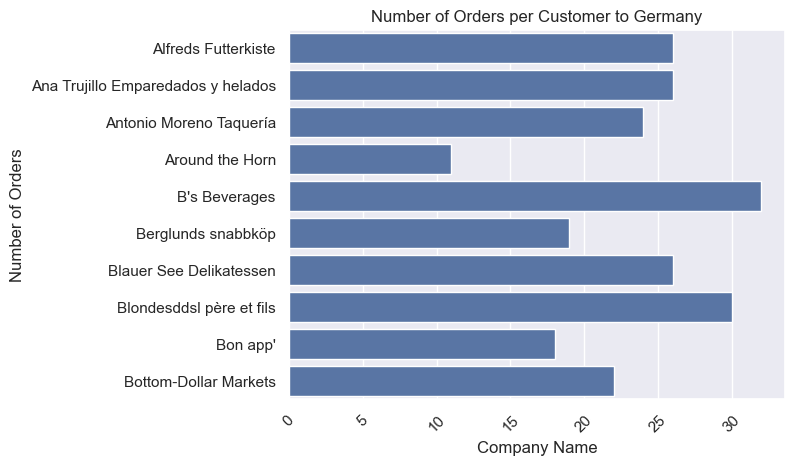

In [22]:
#a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

import seaborn as sns
import matplotlib.pyplot as plt

# count orders per customer
orders = df_details.groupby("CompanyName")["OrderID"].nunique().head(10) #nunique() gives real numbers of orders (*ChatGPT recommnedation)

# convert to DataFrame for seaborn
orders = orders.reset_index(name="orders")

# plot
sns.barplot(data=orders, x="orders", y="CompanyName")
plt.xlabel("Company Name")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.title("Number of Orders per Customer to Germany")
plt.show()


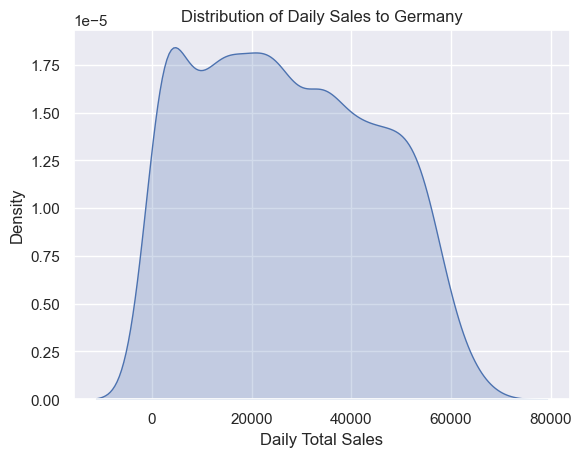

In [23]:
#b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

import seaborn as sns

# calculating total sales per day
daily_sales = df_details.groupby('OrderDate')['LineTotal'].sum().reset_index()

# KDE plot
sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)
plt.xlabel('Daily Total Sales')
plt.ylabel('Density')
plt.title("Distribution of Daily Sales to Germany")
plt.show()



,CategoryName,CategoryLineTotal
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


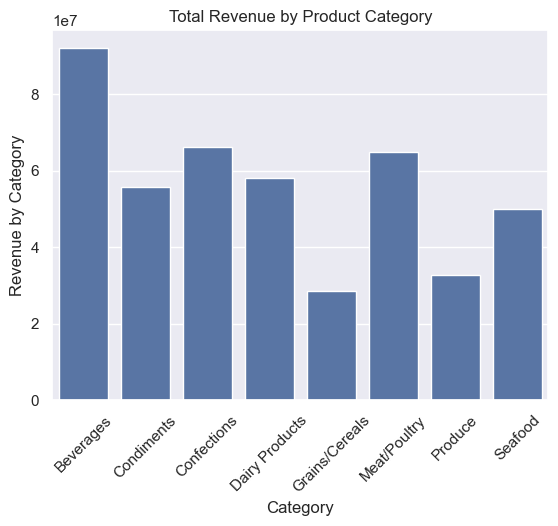

In [25]:
#c) Write a new SQL query that joins OrderDetails, Products, and Categories using inner joins to compute the total revenue (UnitPrice * Quantity) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

import pandas as pd

query = """
    SELECT  c.CategoryName,  
            SUM(od.UnitPrice * od.Quantity) AS CategoryLineTotal 
    FROM "Order Details" od
    JOIN Products p ON p.ProductId=od.ProductId 
    JOIN Categories c ON c.CategoryId=p.CategoryId 
    GROUP BY  c.CategoryName
    """

# load to DataFrame
df_categorydetails = pd.read_sql_query(query, connection)

display(df_categorydetails)

#create bar plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_categorydetails, x='CategoryName',y='CategoryLineTotal')

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue by Category")

plt.xticks(rotation=45)

plt.show()


Task 7: Comparing Python to SQL

In [26]:
#a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

import pandas as pd

# Products table
df_products = pd.read_sql_query("SELECT * FROM Products", connection)
display(df_products.head())

# Categories table
df_categories = pd.read_sql_query("SELECT * FROM Categories", connection)
display(df_categories.head())


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [27]:
#b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

import pandas as pd

inner = pd.merge(df_categories, df_products, how="inner", on="CategoryID")

display(inner.head())

,CategoryID,CategoryName,Description,Picture,ProductID,ProductName,SupplierID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,1,Chai,1,10 boxes x 20 bags,18.0,39,0,10,0
1,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,2,Chang,1,24 - 12 oz bottles,19.0,17,40,25,0
2,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,24,Guaraná Fantástica,10,12 - 355 ml cans,4.5,20,0,0,1
3,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,34,Sasquatch Ale,16,24 - 12 oz bottles,14.0,111,0,15,0
4,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,35,Steeleye Stout,16,24 - 12 oz bottles,18.0,20,0,15,0


In [28]:
#c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using %%time or time.time(), compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.import time

import time

# sql version
start_sql = time.time() #(ChatGPT suggested code line)

query = """
    SELECT  c.CategoryName,  
            SUM(od.UnitPrice * od.Quantity) AS CategoryLineTotal 
    FROM "Order Details" od
    JOIN Products p ON p.ProductId=od.ProductId 
    JOIN Categories c ON c.CategoryId=p.CategoryId 
    GROUP BY  c.CategoryName
    """
df_sql = pd.read_sql_query(query, connection)
display(df_sql)

end_sql = time.time()
sql_time = end_sql - start_sql
print(f"SQL execution time: {sql_time:.4f} seconds")


,CategoryName,CategoryLineTotal
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


SQL execution time: 0.4552 seconds


In [104]:
#version with pandas

start_py = time.time()

# Load full tables
df_od = pd.read_sql_query('SELECT * FROM "Order Details"', connection)
df_products = pd.read_sql_query('SELECT * FROM Products', connection)
df_categories = pd.read_sql_query('SELECT * FROM Categories', connection)

# Merge tables
df_innermerged = pd.merge(df_od, df_products, on="ProductID")
df_innermerged = pd.merge(df_innermerged, df_categories, on="CategoryID")

# Compute revenue
df_innermerged["CategoryLineTotal"] = df_innermerged["UnitPrice_x"] * df_innermerged["Quantity"]

# Group by category
df_py = df_innermerged.groupby("CategoryName")["CategoryLineTotal"].sum().reset_index()


end_py = time.time()
py_time = end_py - start_py

display(df_py)
print(f"Pandas execution time: {py_time:.4f} seconds")

,CategoryName,CategoryLineTotal
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Pandas execution time: 1.1234 seconds


In [108]:
# Comment on which was faster

print(f"\nSQL-only: {sql_time:.4f} seconds")
print(f"\nPandas: {py_time:.4f} seconds")
if sql_time < py_time:
    print("SQL-only was faster.")
else:
    print("Python/pandas was faster.")


SQL-only: 0.5716 seconds

Pandas: 1.1234 seconds
SQL-only was faster.


Task 8: Wide and long format

In [29]:
#a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.
import pandas as pd

# Original wide format

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
print("Wide format:")
display(wide_data)

Wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [30]:
# Convert wide_data to long format

wide_long = wide_data.melt(
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)
print("\nLong format:")
display(wide_long)


Long format:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [31]:
#b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

# Original long_data format

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
print("Long format:")
display(long_data)

Long format:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [32]:
# Convert long_data to wide format

long_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).rename_axis(columns=None).reset_index()

print("\nWide format:")
display(long_wide)


Wide format:


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [33]:
#c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.
    
# Convert wide format back to long

back_to_wide = wide_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).rename_axis(columns=None).reset_index()

print("Original wide format:")
display(wide_data)

print("Back to wide format:")
display(back_to_wide)

Original wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Back to wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [34]:
# Convert long format back to wide

back_to_long = pd.melt(
    long_wide,
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

#to preserve the initial month order, as by default it sets alphabetically from February-Jan-March, ChatGPT suggested to add .Categorical data type to set a specific order
month_order = ["Jan", "Feb", "Mar"] 

back_to_long["month"] = pd.Categorical(
    back_to_long["month"],
    categories=month_order,
    ordered=True
)
# with .Categorical .sort_values keeps logical structure rather than alphabetical one
back_to_long = back_to_long.sort_values(by=["month", "product"]).reset_index(drop=True)

print("Original long format:")
display(long_data)

print("\nBack to long format:")
display(back_to_long)


Original long format:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130



Back to long format:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [35]:
# I also tried to verify the correctness, but it shows False in case of a long table with month, product, and units_sold, even though I fixed the order of the column values.

print(back_to_wide.equals(wide_data))
print(back_to_long.equals(long_data))

True
False
